# Distributed Graph Matching - Interactive Visualization

Run the cells below in order to generate graphs, run algorithms, and analyze results.

## ⚙️ Configuration

**Edit the values in the cell below to customize the simulation**

In [1]:
import sys
sys.path.insert(0, '/Users/tduani/PycharmProjects/distributed_node_matching')

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display
import random

from src.graph import GraphManager
from src.algorithms.implementations import ItaiIsraeliMaximalMatching
from src.simulation import Scheduler, SimulationConfig

print("✅ Imports successful")

✅ Imports successful


In [2]:
# ═══════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION - EDIT THESE PARAMETERS
# ═══════════════════════════════════════════════════════════════

# Graph Generation
NODE_COUNT = 10                      # Number of nodes: 2-50 recommended
EDGE_DENSITY = 0.4                  # Edge ratio: 0.0 to 1.0
GRAPH_TYPE = 'random'               # Type: 'random', 'sparse', 'dense', 'complete', 'disconnected'
SEED = 42                           # Set to None for random seed each time

# Algorithm Execution
MAX_ROUNDS = 1000                   # Maximum simulation rounds

# Visualization
FIGURE_SIZE = (12, 8)               # Figure dimensions
LAYOUT_ITERATIONS = 50              # Graph layout iterations (higher = better spacing)
NODE_SIZE = 50                     # Node circle size
FONT_SIZE = 10                      # Font size for node labels
SHOW_EDGE_WEIGHTS = True            # Show edge weights on graph

# ═══════════════════════════════════════════════════════════════

print(f"""
╔════════════════════════════════════════════════════════════╗
║              SIMULATION CONFIGURATION                      ║
╠════════════════════════════════════════════════════════════╣
║  Nodes:        {NODE_COUNT}
║  Edge Density: {EDGE_DENSITY}
║  Graph Type:   {GRAPH_TYPE}
║  Max Rounds:   {MAX_ROUNDS}
║  Seed:         {SEED}
╚════════════════════════════════════════════════════════════╝
""")

# Global storage for results
results = {
    'graph': None,
    'snapshots': None,
    'final_matching': None,
    'metrics': None,
    'convergence_rounds': 0
}


╔════════════════════════════════════════════════════════════╗
║              SIMULATION CONFIGURATION                     ║
╠════════════════════════════════════════════════════════════╣
║  Nodes:        10
║  Edge Density: 0.4
║  Graph Type:   random
║  Max Rounds:   1000
║  Seed:         42
╚════════════════════════════════════════════════════════════╝



## 1️⃣ Generate Graph

In [3]:
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)

graph = GraphManager.create_empty_graph()
for i in range(1, NODE_COUNT + 1):
    graph.add_vertex(i)

vertex_list = list(range(1, NODE_COUNT + 1))
edges_added = set()

if GRAPH_TYPE == "complete":
    for i, u in enumerate(vertex_list):
        for v in vertex_list[i + 1:]:
            weight = random.uniform(0.0, 1.0)
            graph.add_edge(u, v, weight)
            edges_added.add((min(u, v), max(u, v)))

elif GRAPH_TYPE == "sparse":
    for u in vertex_list:
        for v in vertex_list:
            if u != v and len(edges_added) < int(NODE_COUNT * NODE_COUNT * 0.1):
                if (min(u, v), max(u, v)) not in edges_added:
                    weight = random.uniform(0.0, 1.0)
                    graph.add_edge(u, v, weight)
                    edges_added.add((min(u, v), max(u, v)))

elif GRAPH_TYPE == "dense":
    for i, u in enumerate(vertex_list):
        for v in vertex_list[i + 1:]:
            if len(edges_added) < int(NODE_COUNT * NODE_COUNT * EDGE_DENSITY):
                weight = random.uniform(0.0, 1.0)
                graph.add_edge(u, v, weight)
                edges_added.add((min(u, v), max(u, v)))

elif GRAPH_TYPE == "disconnected":
    mid = NODE_COUNT // 2
    for i in range(1, mid):
        weight = random.uniform(0.0, 1.0)
        graph.add_edge(i, i + 1, weight)
        edges_added.add((i, i + 1))
    for i in range(mid + 1, NODE_COUNT):
        weight = random.uniform(0.0, 1.0)
        graph.add_edge(i, i + 1, weight)
        edges_added.add((i, i + 1))

else:
    max_possible_edges = NODE_COUNT * (NODE_COUNT - 1) // 2
    target_edges = int(max_possible_edges * EDGE_DENSITY)
    
    while len(edges_added) < target_edges:
        u = random.choice(vertex_list)
        v = random.choice(vertex_list)
        if u != v and (min(u, v), max(u, v)) not in edges_added:
            weight = random.uniform(0.0, 1.0)
            graph.add_edge(u, v, weight)
            edges_added.add((min(u, v), max(u, v)))

results['graph'] = graph

print(f"✅ Graph generated:")
print(f"   Nodes: {len(graph.vertices())}")
print(f"   Edges: {len(edges_added)}")
print(f"   Edges: {edges_added}")
print(f"   Density: {len(edges_added) / max(1, NODE_COUNT * (NODE_COUNT - 1) / 2):.2%}")

✅ Graph generated:
   Nodes: 10
   Edges: 18
   Edges: {(4, 10), (2, 4), (1, 2), (2, 7), (5, 8), (1, 8), (1, 4), (2, 3), (2, 9), (7, 9), (5, 10), (2, 6), (5, 6), (1, 10), (6, 10), (3, 6), (4, 5), (1, 3)}
   Density: 40.00%


## 2️⃣ Visualize Generated Graph

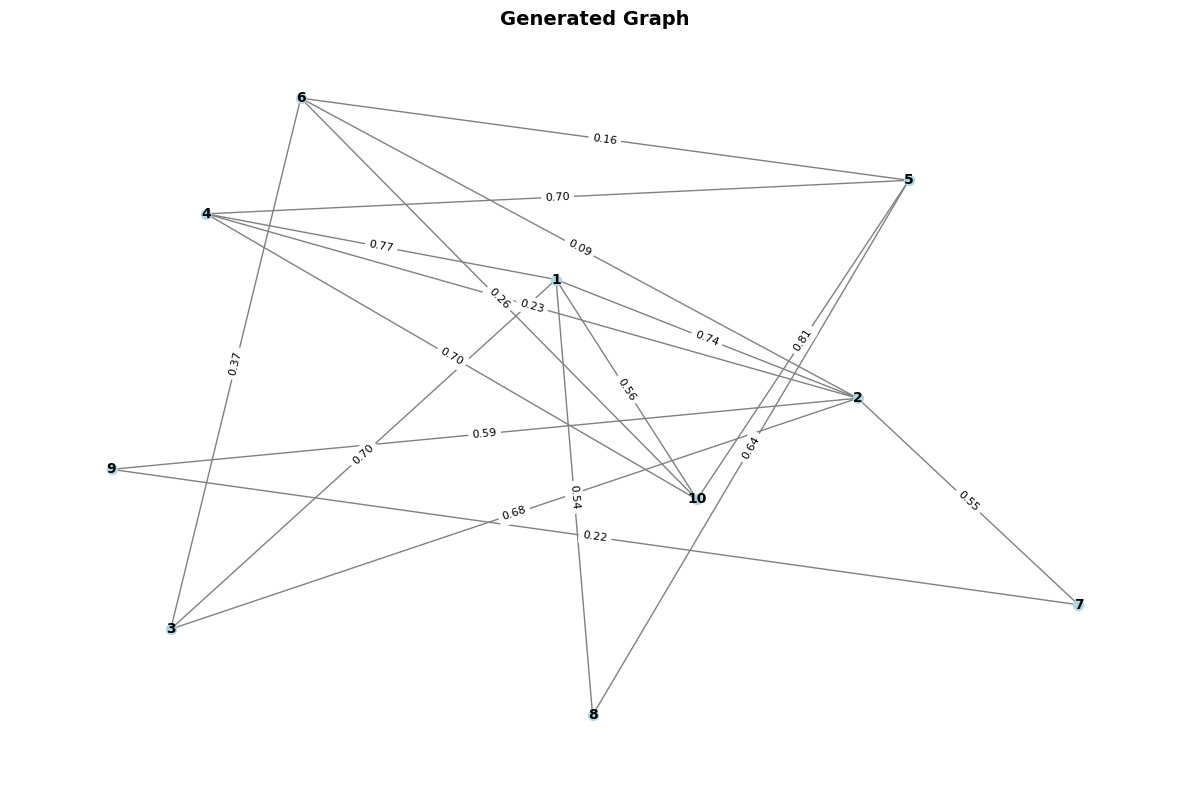

✅ Graph visualization complete


In [4]:
graph = results['graph']
G = nx.Graph()
for v in graph.vertices():
    G.add_node(v)
for u, v in graph._graph.edges():
    weight = graph.get_edge_weight(u, v)
    G.add_edge(u, v, weight=weight)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
pos = nx.spring_layout(G, seed=SEED, k=2, iterations=LAYOUT_ITERATIONS)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=NODE_SIZE, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=FONT_SIZE, font_weight='bold', ax=ax)

if SHOW_EDGE_WEIGHTS:
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, ax=ax)

ax.set_title('Generated Graph', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ Graph visualization complete")

## 3️⃣ Run Algorithm

In [5]:
print("Running Itai-Israeli Maximal Matching algorithm...")

graph = results['graph']
algo = ItaiIsraeliMaximalMatching(seed=SEED)
config = SimulationConfig(
    max_rounds=MAX_ROUNDS,
    collect_snapshots=True,
    random_seed=SEED
)
scheduler = Scheduler(graph, algo, config)
rounds = scheduler.run_until_termination()

results['snapshots'] = scheduler.state_store.get_snapshots()
results['final_matching'] = scheduler.final_matching
results['metrics'] = scheduler.metrics.get_all_metrics()
results['convergence_rounds'] = rounds

print(f"✅ Algorithm completed:")
print(f"   Convergence rounds: {rounds}")
print(f"   Total snapshots: {len(results['snapshots'])}")
print(f"   Final matching: {results['final_matching']}")
print(f"   Matched pairs: {len(results['final_matching']) // 2}")

Running Itai-Israeli Maximal Matching algorithm...
✅ Algorithm completed:
   Convergence rounds: 151
   Total snapshots: 151
   Final matching: {1: 8, 2: 3, 3: 2, 6: 10, 7: 9, 8: 1, 9: 7, 10: 6}
   Matched pairs: 4


## 4️⃣ Visualize Results (Graph with Matching)

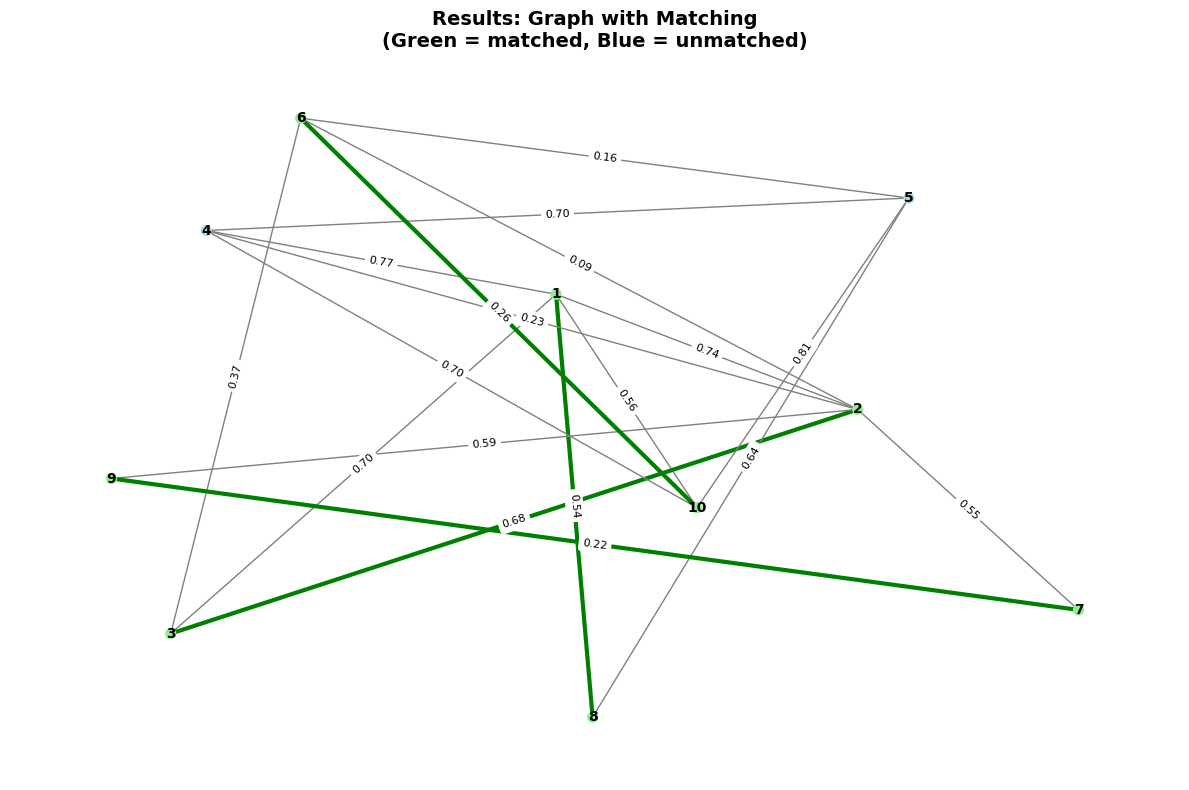

✅ Results visualization complete


In [6]:
graph = results['graph']
matching = results['final_matching']

G = nx.Graph()
for v in graph.vertices():
    G.add_node(v)
for u, v in graph._graph.edges():
    weight = graph.get_edge_weight(u, v)
    G.add_edge(u, v, weight=weight)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
pos = nx.spring_layout(G, seed=SEED, k=2, iterations=LAYOUT_ITERATIONS)

node_colors = ['lightgreen' if matching.get(n) is not None else 'lightblue' 
               for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=NODE_SIZE, ax=ax)

edge_colors = []
edge_widths = []
for u, v in G.edges():
    is_matched = (matching.get(u) == v and matching.get(v) == u)
    edge_colors.append('green' if is_matched else 'gray')
    edge_widths.append(3 if is_matched else 1)

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=FONT_SIZE, font_weight='bold', ax=ax)

if SHOW_EDGE_WEIGHTS:
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, ax=ax)

ax.set_title('Results: Graph with Matching\n(Green = matched, Blue = unmatched)', 
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ Results visualization complete")

## 5️⃣ Metrics & Performance Analysis

In [7]:
metrics = results['metrics']

data = []
for m in metrics:
    data.append({
        'Round': m.round_num,
        'Active': m.active_nodes,
        'Matched': m.matched_nodes,
        'Unmatched': m.unmatched_vertices,
        'Messages': m.messages_sent,
        'Duration (ms)': f"{m.round_duration_ms:.3f}"
    })

df = pd.DataFrame(data)
print("\n📊 Metrics Table:")
display(df)

print("\n📈 Summary:")
print(f"   Total rounds: {len(metrics)}")
print(f"   Total messages: {sum(m.messages_sent for m in metrics)}")
print(f"   Peak active nodes: {max(m.active_nodes for m in metrics)}")
print(f"   Final matched nodes: {metrics[-1].matched_nodes}")
print(f"   Final unmatched nodes: {metrics[-1].unmatched_vertices}")


📊 Metrics Table:


,Round,Active,Matched,Unmatched,Messages,Duration (ms)
0,0,0,0,0,10,0.000
1,1,0,0,0,14,0.000
2,2,0,0,0,17,0.000
3,3,0,0,0,17,0.000
4,4,0,0,0,17,0.000
...,...,...,...,...,...,...
96,96,0,0,0,17,0.000
97,97,0,0,0,17,0.000
98,98,0,0,0,17,0.000
99,99,0,0,0,17,0.000



📈 Summary:
   Total rounds: 101
   Total messages: 1707
   Peak active nodes: 0
   Final matched nodes: 0
   Final unmatched nodes: 0


## 6️⃣ Performance Charts

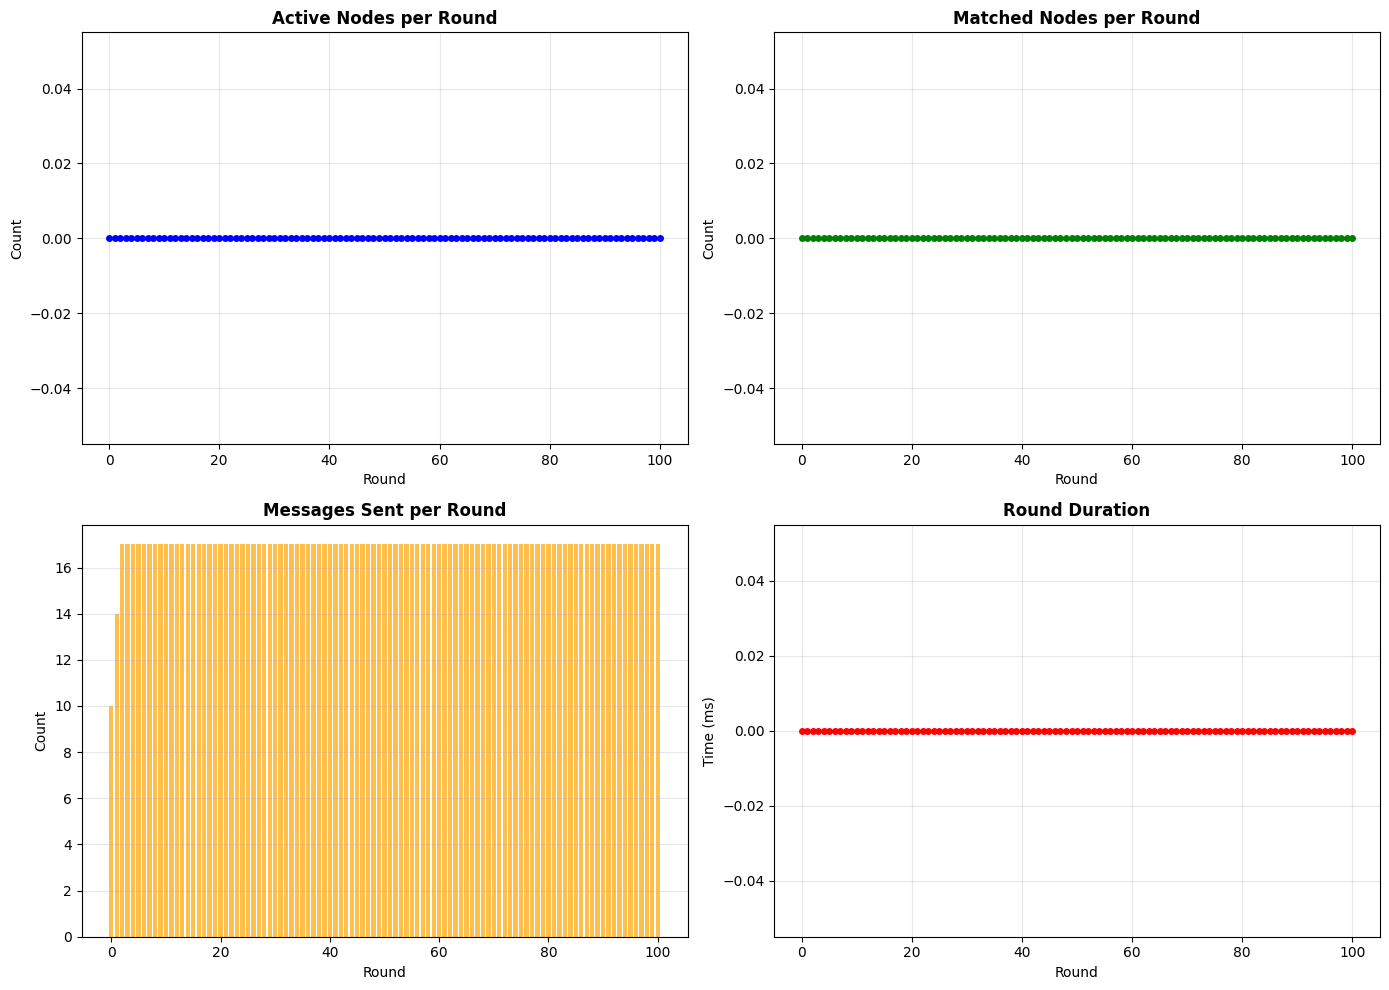

✅ Charts complete


In [8]:
metrics = results['metrics']

rounds = [m.round_num for m in metrics]
active = [m.active_nodes for m in metrics]
matched = [m.matched_nodes for m in metrics]
messages = [m.messages_sent for m in metrics]
duration = [m.round_duration_ms for m in metrics]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(rounds, active, 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_title('Active Nodes per Round', fontweight='bold')
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(rounds, matched, 'g-o', linewidth=2, markersize=4)
axes[0, 1].set_title('Matched Nodes per Round', fontweight='bold')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].bar(rounds, messages, color='orange', alpha=0.7)
axes[1, 0].set_title('Messages Sent per Round', fontweight='bold')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].plot(rounds, duration, 'r-o', linewidth=2, markersize=4)
axes[1, 1].set_title('Round Duration', fontweight='bold')
axes[1, 1].set_xlabel('Round')
axes[1, 1].set_ylabel('Time (ms)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Charts complete")

## 7️⃣ Inspect Any Round

Change `ROUND_TO_INSPECT` below to examine state at any round

In [9]:
# Change this number to inspect any round
ROUND_TO_INSPECT = len(results['snapshots']) - 1  # Last round by default

snapshots = results['snapshots']
snap = snapshots[ROUND_TO_INSPECT]

print(f"""
╔════════════════════════════════════════════════════════════╗
║  ROUND {snap.round_num}
╚════════════════════════════════════════════════════════════╝
""")

print(f"Node States:")
for node_id in sorted(snap.node_states.keys()):
    state = snap.node_states[node_id]
    status = state.get('status', 'unknown')
    matched_to = state.get_matched_to()
    active = state.get('active', False)
    neighbors = len(state.get('neighbors', []))
    
    matched_str = f"→ {matched_to}" if matched_to is not None else "(unmatched)"
    active_str = "[ACTIVE]" if active else ""
    
    print(f"  Node {node_id}: {status:<8} {matched_str:<10} neighbors={neighbors} {active_str}")

print(f"\nMeta State:")
print(f"  Converged: {snap.meta_state.converged}")
print(f"  Termination: {snap.meta_state.termination_reason}")


╔════════════════════════════════════════════════════════════╗
║  ROUND 101
╚════════════════════════════════════════════════════════════╝

Node States:
  Node 1: unknown  → 8        neighbors=5 
  Node 2: unknown  (unmatched) neighbors=6 [ACTIVE]
  Node 3: unknown  (unmatched) neighbors=3 [ACTIVE]
  Node 4: unknown  (unmatched) neighbors=4 [ACTIVE]
  Node 5: unknown  (unmatched) neighbors=4 [ACTIVE]
  Node 6: unknown  → 10       neighbors=4 
  Node 7: unknown  → 9        neighbors=2 
  Node 8: unknown  → 1        neighbors=2 
  Node 9: unknown  → 7        neighbors=2 
  Node 10: unknown  → 6        neighbors=4 

Meta State:
  Converged: False
  Termination: None


## 📝 Summary & Usage

**How to use:**
1. Edit the parameters in Cell 2 (⚙️ Configuration)
2. Run cells 1-7 in order

**Parameters reference:**
- `NODE_COUNT`: 2-50 nodes (try 8-15)
- `EDGE_DENSITY`: 0.2-0.6 is good for visualization
- `GRAPH_TYPE`: different structures for testing
- `MAX_ROUNDS`: higher = longer simulation
- `SEED`: None = random each run, 42 = reproducible

**Graph visualization legend:**
- 🟢 Green nodes = matched in the solution
- 🔵 Blue nodes = unmatched
- Green thick edges = matched pairs
- Gray thin edges = unmatched

**Tips:**
- Start with default settings and adjust
- Larger graphs take longer to compute
- Higher edge density = more matching pairs
- Check Cell 7 to inspect any specific round